In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.config import Configuration
CONFIG = Configuration()

In [2]:
from maikol_utils.file_utils import list_dir_files

train_files, _ = list_dir_files(CONFIG.faces_test_path)
test_files, _ = list_dir_files(CONFIG.faces_train_path)

set(train_files).intersection(set(test_files))

set()

# Test

In [3]:
import os
import cv2
from src.model import load_cascade, CascadeClassifier

# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_18_fpr_0.0000000000_99_pfp.xml')
# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_21_fpr_0.0000000000_999_pfp.xml')
# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_14_fpr_0.0000052185.xml')
# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_11_fpr_0.0000248881.xml')

# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_23_fpr_0.0000000000_99.xml')
# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_28_fpr_0.0000000000_999.xml')
cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_21_fpr_0.0000004014_999_pfp_all.xml')



cascade = load_cascade(cascade_path)
CONFIG.crop_size = max(cascade.height, cascade.width)
classifier = CascadeClassifier(CONFIG, cascade)

Loading Haar cascade from: ../models/haar_cascades_computed_best/haar_cascade_stage_21_fpr_0.0000004014_999_pfp_all.xml


In [4]:
from src.data import get_image_crops_from_list

from maikol_utils.file_utils import list_dir_files

all_crops, cn = list_dir_files(CONFIG.no_faces_crops_path)
# all_crops, cn = list_dir_files(os.path.join('..', 'data', 'ViolaJones', 'pacheco', 'dataset', 'background_crops'))
# all_crops, cn = list_dir_files('../data/ViolaJones/pacheco/dataset/background_crops')
# test_faces, tn = list_dir_files(CONFIG.faces_test_path)
# test_faces, tn = list_dir_files(CONFIG.faces_vpc_path)
test_faces, tn = list_dir_files(CONFIG.faces_test_path)
print(f"Total crops in no_facescrops directory: {cn}")
print(f"Total crops in faces_test directory: {tn}")




Total crops in no_facescrops directory: 2491154
Total crops in faces_test directory: 5122


In [5]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import os

max_workers = min(32, (os.cpu_count() or 1) * 2)

def _predict_one(img_path):
    fps, candidates = classifier.predict_no_merge(img_path=img_path, return_candidate_count=True)
    return img_path, fps, candidates

all_fps, total_candidates = [], 0
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    results = ex.map(_predict_one, all_crops)
    for img_path, fps, candidates in tqdm(results, total=len(all_crops), desc="No-faces eval"):
        all_fps.extend({"path": img_path, "face": face} for face in fps)
        total_candidates += candidates

fpr = (len(all_fps) / total_candidates) if total_candidates else 0.0
print(f"Number of candidates: {total_candidates}")
print(f"Number of detections: {len(all_fps)}")
print(f"False Positive Rate: {fpr:.10%}")

No-faces eval: 100%|██████████| 2491154/2491154 [02:42<00:00, 15313.27it/s]

Number of candidates: 2491154
Number of detections: 1
False Positive Rate: 0.0000401420%


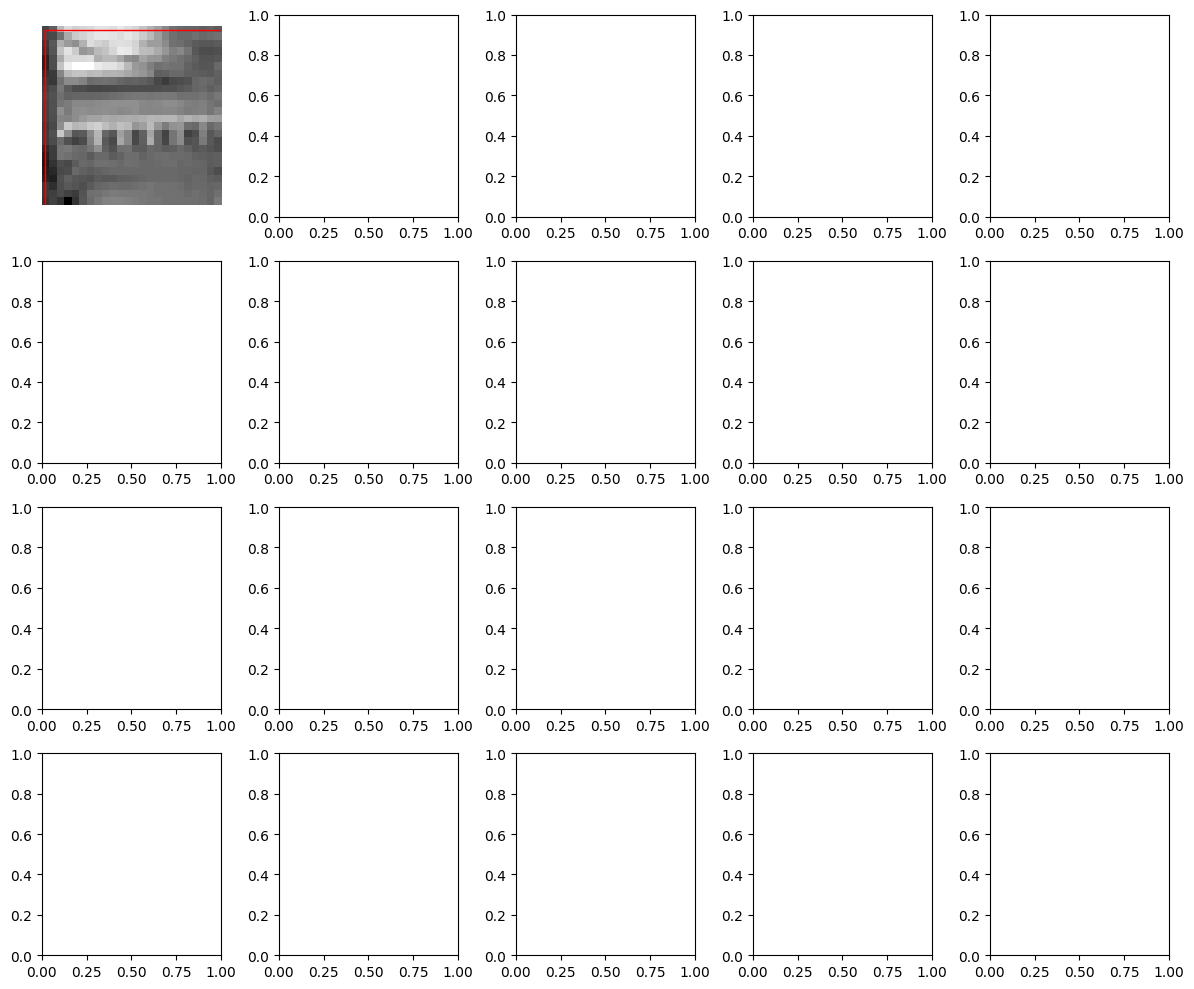

In [6]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

sample = random.sample(all_fps, min(20, len(all_fps)))

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, item in zip(axes.flat, sample):
    # img = Image.open(item["path"])
    img = Image.open(item["path"]).convert("L")
    f = item["face"]
    ax.imshow(img, cmap="gray")
    ax.add_patch(
        patches.Rectangle(
            (f["x"], f["y"]), f["w"], f["h"], linewidth=1, edgecolor="red", facecolor="none")
        )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import os

max_workers = min(32, (os.cpu_count() or 1) * 2)

def _predict_one_face(img_path):
    faces, candidates = classifier.predict(
        img_path=img_path,
        return_candidate_count=True
    )
    return img_path, faces, candidates

all_faces, total_candidates, right_predictions = [], 0, 0
missed_test_face_paths = []
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    results = ex.map(_predict_one_face, test_faces)
    for img_path, faces, candidates in tqdm(results, total=len(test_faces), desc="Faces eval"):
        all_faces.extend(faces)
        if len(faces) > 0:
            right_predictions += 1
        else:
            missed_test_face_paths.append(img_path)
        total_candidates += candidates

tpr = (right_predictions / len(test_faces)) if len(test_faces) else 0.0
print(f"Number of candidates: {total_candidates}")
print(f"Number of detections: {len(all_faces)}")
print(f"True Positive Rate: {tpr:.4%}")
print(f"Missed test face images: {len(missed_test_face_paths)}")

Faces eval: 100%|██████████| 5122/5122 [00:00<00:00, 11235.91it/s]

Number of candidates: 5122
Number of detections: 5066
True Positive Rate: 98.9067%
Missed test face images: 56


In [8]:
i = 0

Total missed test-face images available: 56


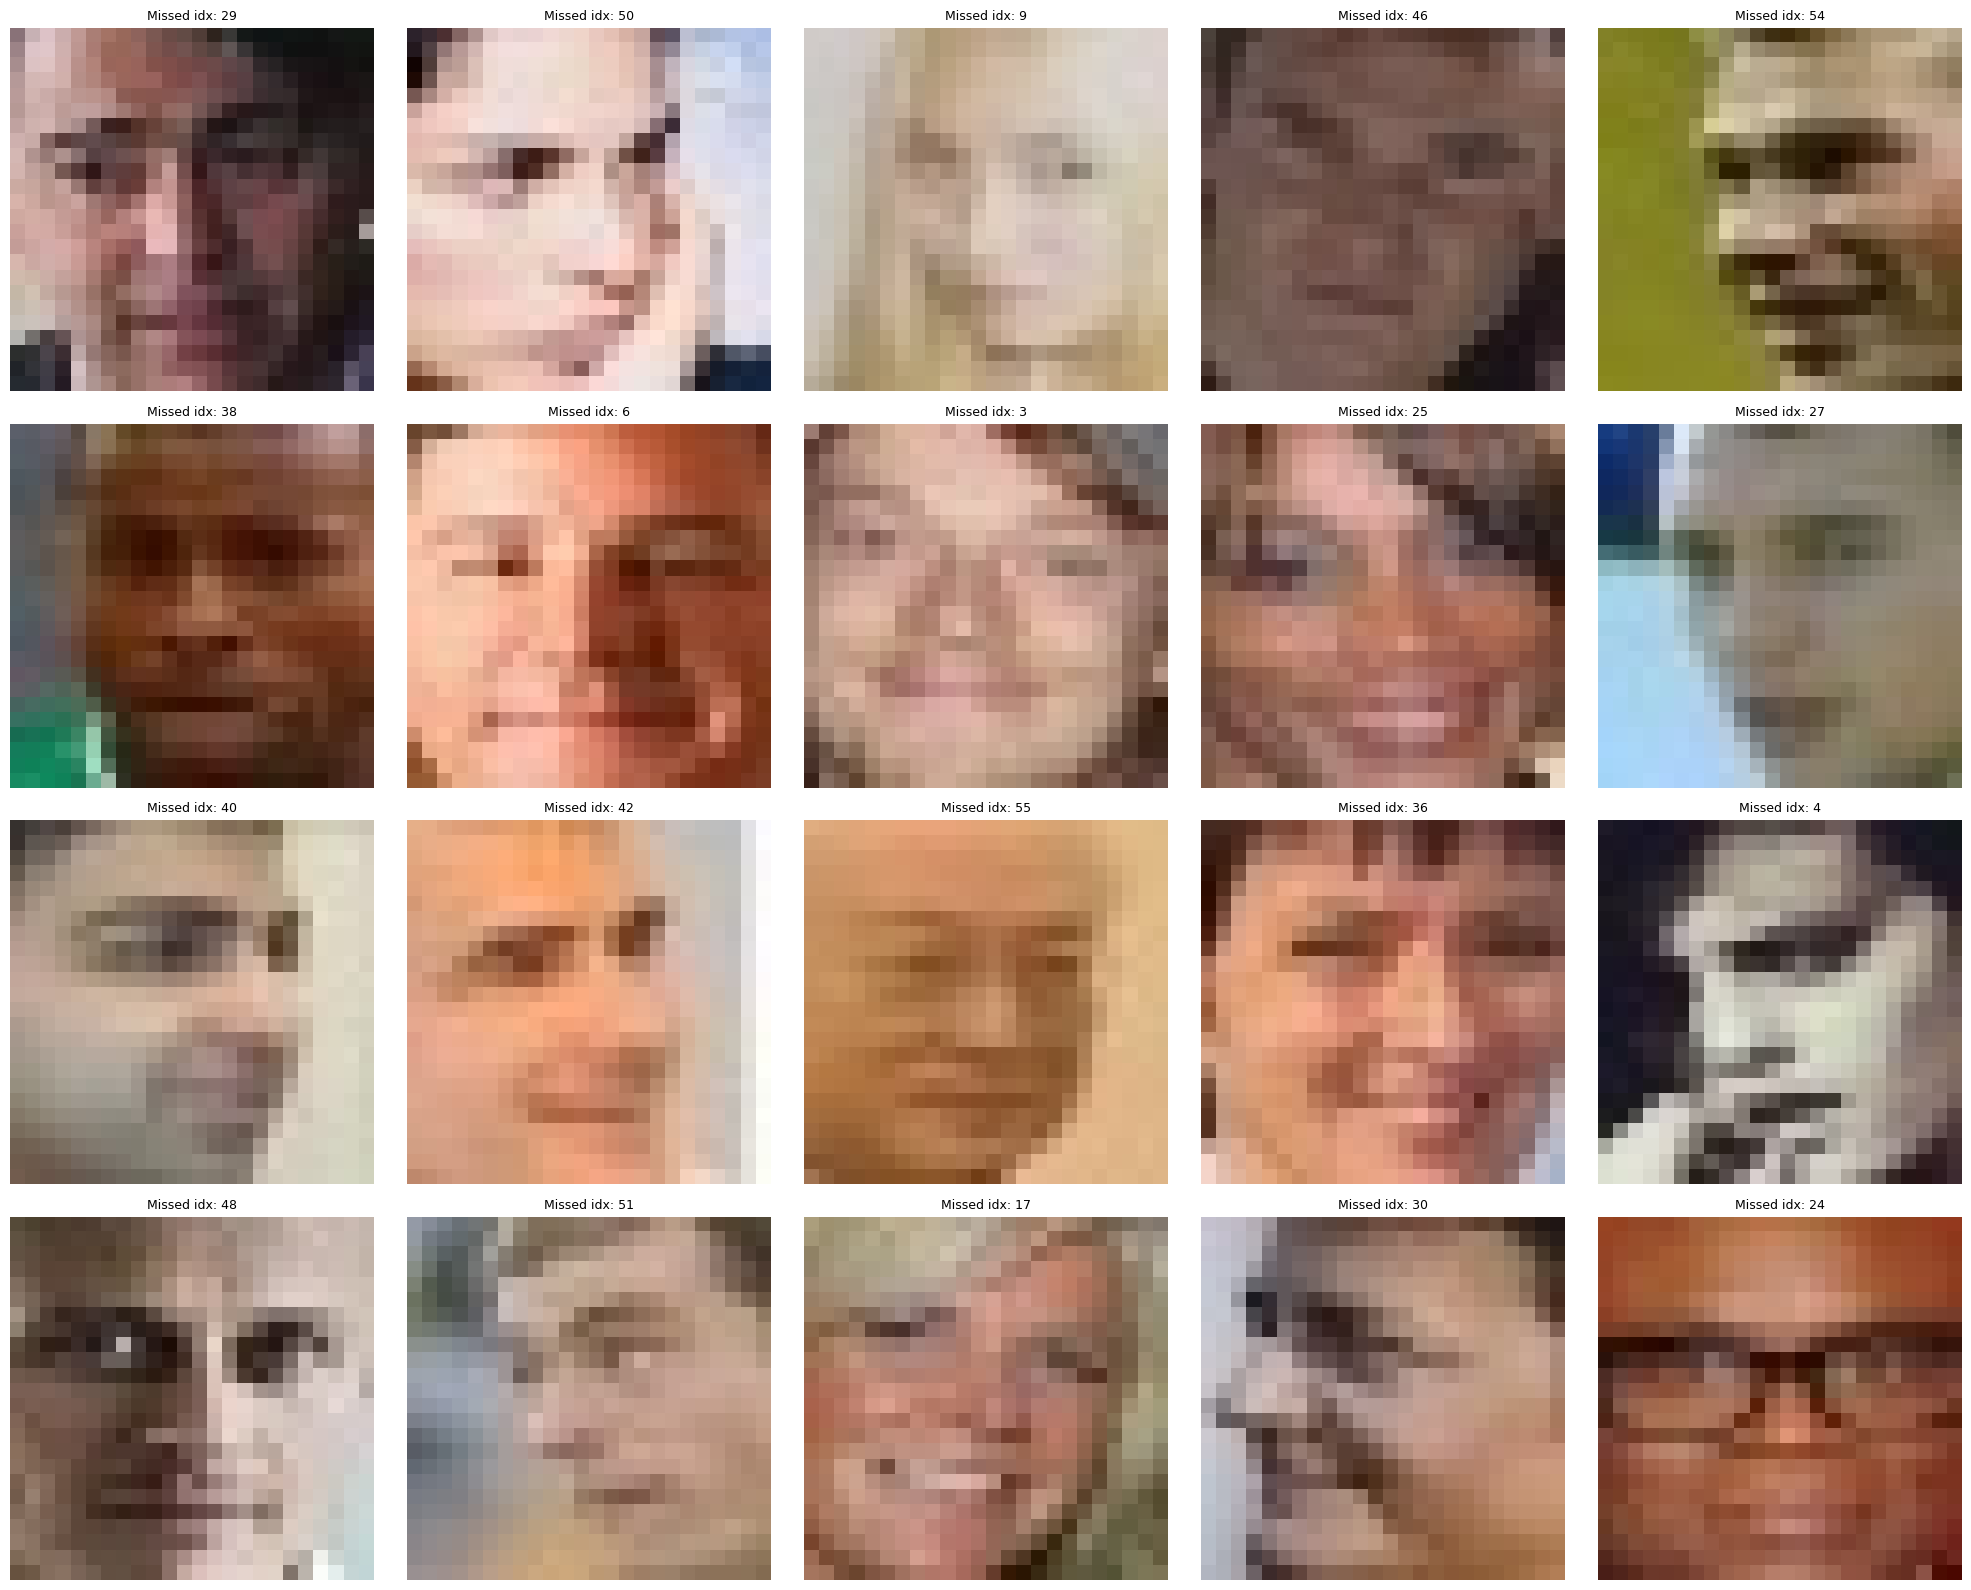

In [9]:
# Plot random missed test-face images (not identified by the detector)
import numpy as np
import matplotlib.pyplot as plt
import cv2

def show_missed_test_images(image_paths, n_rows=4, n_cols=5, figsize=(20, 16), seed=None):
    total_slots = n_rows * n_cols
    n_available = len(image_paths)
    if n_available == 0:
        print("No missed test face images to plot.")
        return

    rng = np.random.default_rng(seed)
    n_samples = min(total_slots, n_available)
    selected_indices = rng.choice(n_available, size=n_samples, replace=False)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    flat_axes = axes.flatten()

    for ax in flat_axes:
        ax.axis("off")

    for ax, idx in zip(flat_axes, selected_indices):
        path = image_paths[idx]
        img = cv2.imread(path)
        if img is None:
            ax.set_title("Unreadable image", fontsize=9)
            continue
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Missed idx: {idx}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

print(f"Total missed test-face images available: {len(missed_test_face_paths)}")

show_missed_test_images(missed_test_face_paths, n_rows=4, n_cols=5, seed=CONFIG.seed + i)
i += 1

# Single Image

In [10]:
# filepath = '../data/ViolaJones/no_faces/open-images-v7/test/data/00a1039917ab1fb3.jpg'
# filepath = '../data/ViolaJones/G21391.jpg'
filepath = '../data/ViolaJones/crowd1.png'
# filepath = '../data/ViolaJones/crowd2.png'
# filepath = '../data/ViolaJones/crowd3.png'
filepath = '../data/ViolaJones/crowd4.png'#
# filepath = '../data/ViolaJones/crowd5.png'
# filepath = '../data/ViolaJones/no_faces/all/0a0a3cef62f69def.jpg'

In [11]:
from src.data import get_image_crops_from_list
faces, candidates = classifier.predict(img_path=filepath, return_candidate_count=True, halve_size=True, halve_size_factor=1)
crops = get_image_crops_from_list(faces, img_path=filepath)

print(f"Number of candidates: {candidates}")
print(f"Number of detections: {len(faces)}")

Number of candidates: 172429
Number of detections: 142


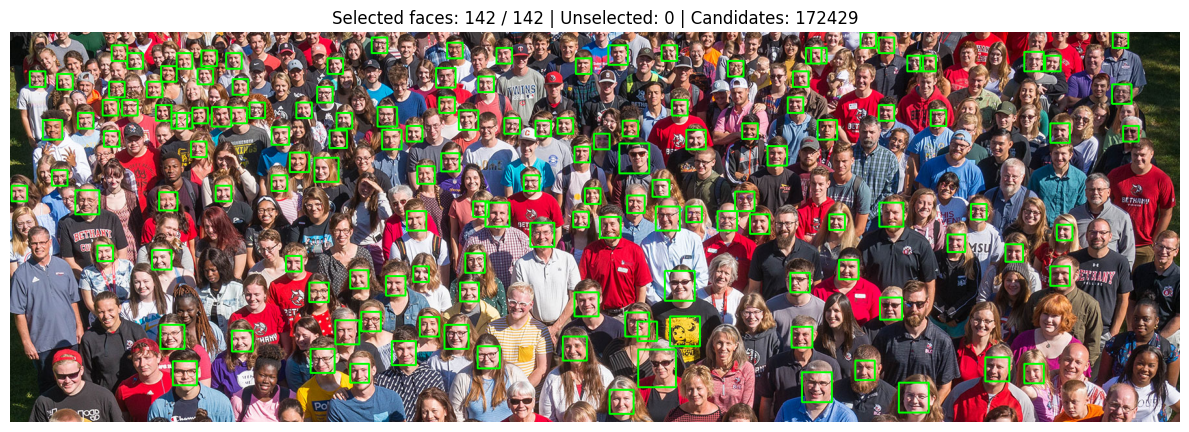

In [12]:
import matplotlib.pyplot as plt
import cv2

def plot_selected_face_squares(img_path, classifier, halve_size_factor=8, selected_indices=None, color=(0, 255, 0), thickness=2, figsize=(12, 8)):
    """
    Run detection on an image path and plot square boxes for selected detections.

    Args:
        img_path (str): Path to image.
        classifier: CascadeClassifier instance with predict method.
        halve_size_factor (int): Factor by which to reduce image size for detection.
        selected_indices (list[int] | int | None):
            - None -> plot all detections
            - int or list[int] -> plot only these detection indices
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")

    faces, candidates = classifier.predict(
        img_path=img_path,
        return_candidate_count=True,
        halve_size=True, halve_size_factor=halve_size_factor
    )

    # Normalize index selection
    if selected_indices is None:
        selected_indices = list(range(len(faces)))
    elif isinstance(selected_indices, int):
        selected_indices = [selected_indices]

    valid_indices = [i for i in selected_indices if 0 <= i < len(faces)]
    selected_set = set(valid_indices)
    selected_faces = [faces[i] for i in valid_indices]
    unselected_faces = [face for i, face in enumerate(faces) if i not in selected_set]

    h_img, w_img = img.shape[:2]
    boxed = img.copy()

    # Remap detections from downscaled detection space back to original image space.
    scale = max(1, int(halve_size_factor))

    for face in selected_faces:
        x = int(face['x'] * scale)
        y = int(face['y'] * scale)
        w = int(face['w'] * scale)
        h = int(face['h'] * scale)

        # Convert each detection to a square centered on the original box
        side = max(w, h)
        cx, cy = x + w // 2, y + h // 2
        x0 = max(0, cx - side // 2)
        y0 = max(0, cy - side // 2)
        x1 = min(w_img - 1, x0 + side)
        y1 = min(h_img - 1, y0 + side)

        cv2.rectangle(boxed, (x0, y0), (x1, y1), color, thickness)

    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
    plt.title(
        f"Selected faces: {len(selected_faces)} / {len(faces)} | Unselected: {len(unselected_faces)} | Candidates: {candidates}"
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return faces, selected_faces, unselected_faces, boxed

# Example usage:
faces, selected_faces, unselected_faces, boxed = plot_selected_face_squares(
    img_path=filepath,
    classifier=classifier,
    halve_size_factor=1,
    selected_indices=None,  # e.g. [0, 2, 5] to plot specific detections only
)

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Build crops from unselected detections returned by the previous cell
unselected_crops = get_image_crops_from_list(unselected_faces, img_path=filepath)
print(f"Unselected detections available: {len(unselected_crops)}")

def show_images(images, indices):
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    flat_axes = axes.flatten()

    for ax in flat_axes:
        ax.axis("off")

    for ax, img, crop_idx in zip(flat_axes, images, indices):
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Unselected Crop Index: {crop_idx}', fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

n_samples = min(20, len(unselected_crops))
if n_samples == 0:
    print("No unselected detections to plot.")
else:
    sample_indices = np.random.choice(len(unselected_crops), size=n_samples, replace=False)
    sample = [unselected_crops[i] for i in sample_indices]
    show_images([item['img'] for item in sample], sample_indices)

Unselected detections available: 0
No unselected detections to plot.
